Análisis de Ventas - Dataset Superstore

Este proyecto tiene como objetivo analizar un dataset de ventas para obtener insights relevantes sobre el rendimiento del negocio.

Se utilizarán herramientas como Python y la librería pandas para la limpieza, transformación y análisis de los datos, así como visualización mediante gráficos.

El análisis se enfocará en:
- Identificar productos más vendidos
- Analizar ventas a lo largo del tiempo
- Evaluar el comportamiento de los clientes
- Detectar patrones en los datos

En esta sección se cargan los datos desde un archivo Excel utilizando pandas.
Se realiza una primera visualización para entender la estructura del dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot  as plt

data = pd.read_excel("final_dataset.xlsx")

print(data.head)

<bound method NDFrame.head of       Row ID        Order ID Order Date  Ship Date       Ship Mode  \
0       7981  CA-2014-103800 2014-01-03 2014-01-07  Standard Class   
1        740  CA-2014-112326 2014-01-04 2014-01-08  Standard Class   
2        741  CA-2014-112326 2014-01-04 2014-01-08  Standard Class   
3        742  CA-2014-112326 2014-01-04 2014-01-08  Standard Class   
4       1760  CA-2014-141817 2014-01-05 2014-01-12  Standard Class   
...      ...             ...        ...        ...             ...   
9989    5092  CA-2017-156720 2017-12-30 2018-01-03  Standard Class   
9990     909  CA-2017-143259 2017-12-30 2018-01-03  Standard Class   
9991     908  CA-2017-143259 2017-12-30 2018-01-03  Standard Class   
9992    1297  CA-2017-115427 2017-12-30 2018-01-03  Standard Class   
9993     907  CA-2017-143259 2017-12-30 2018-01-03  Standard Class   

     Customer ID      Customer Name      Segment        Country  \
0       DP-13000      Darren Powers     Consumer  United State

Se exploran las características generales del dataset, incluyendo:
- Tipos de datos
- Valores nulos
- Estructura de columnas





In [ ]:
data.info()
print(data.columns)
print(data.describe())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n


En esta etapa se realiza la limpieza de los datos para asegurar su calidad.

Se convierten las columnas de fechas al formato correcto para poder trabajar con ellas.
Además, se eliminan valores nulos para evitar errores en el análisis.

Este paso es fundamental ya que un dataset limpio permite obtener resultados más confiables.




In [ ]:
data["Order Date"] = pd.to_datetime(data["Order Date"])
data["Ship Date"] = pd.to_datetime(data["Ship Date"])

data = data.dropna() #eliminar nulos
# data = data.drop_duplicates()  eliminar duplicados
# data["columna"] = data["columna"].fillna(0) rellenar los nulos con 0


En esta sección se crean nuevas variables a partir de los datos originales.

Se extraen el mes y el año de la fecha de pedido para facilitar el análisis temporal.
También se define una columna de ventas totales que será utilizada en los cálculos posteriores.

Estas transformaciones permiten simplificar y mejorar el análisis de los datos.


In [ ]:
data["Month"] = data["Order Date"].dt.month
data["Year"] = data["Order Date"].dt.year

In [ ]:
sales_by_month = data.groupby("Month")["Sales"].sum().sort_values()
print(sales_by_month)

Month
2      59751.2514
1      94924.8356
4     137762.1286
7     147238.0970
6     152718.6793
5     155028.8117
8     159044.0630
10    200322.9847
3     205005.4888
9     307649.9457
12    325293.5035
11    352461.0710
Name: Sales, dtype: float64


En esta etapa se realiza el análisis de los datos para responder preguntas clave del negocio.

Se analizan:
- Ventas por mes para identificar tendencias
- Productos más vendidos
- Ventas por categoría
- Clientes que generan más ingresos
- Rentabilidad por categoría

Este análisis permite entender el comportamiento general de las ventas.

In [ ]:
top_products = data.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [ ]:
sales_by_category = data.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(sales_by_category)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [ ]:
top_customers = data.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [ ]:
profit_by_category = data.groupby("Category")["Profit"].sum().sort_values(ascending=False)
print(profit_by_category)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


En este gráfico se visualizan las ventas a lo largo del tiempo.

Esto permite identificar tendencias, como meses con mayor o menor cantidad de ventas,
y analizar la evolución del negocio.


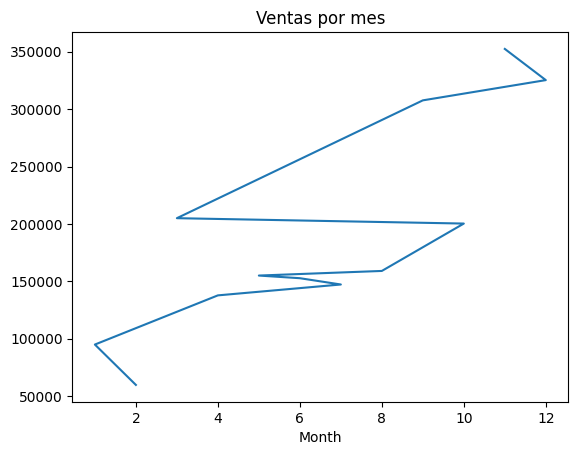

In [ ]:
sales_by_month.plot(kind="line", title="Ventas por mes")
plt.show()


En este gráfico se muestran los productos más vendidos.

Esto permite identificar cuáles son los productos más importantes para el negocio
y cuáles generan mayor volumen de ventas.


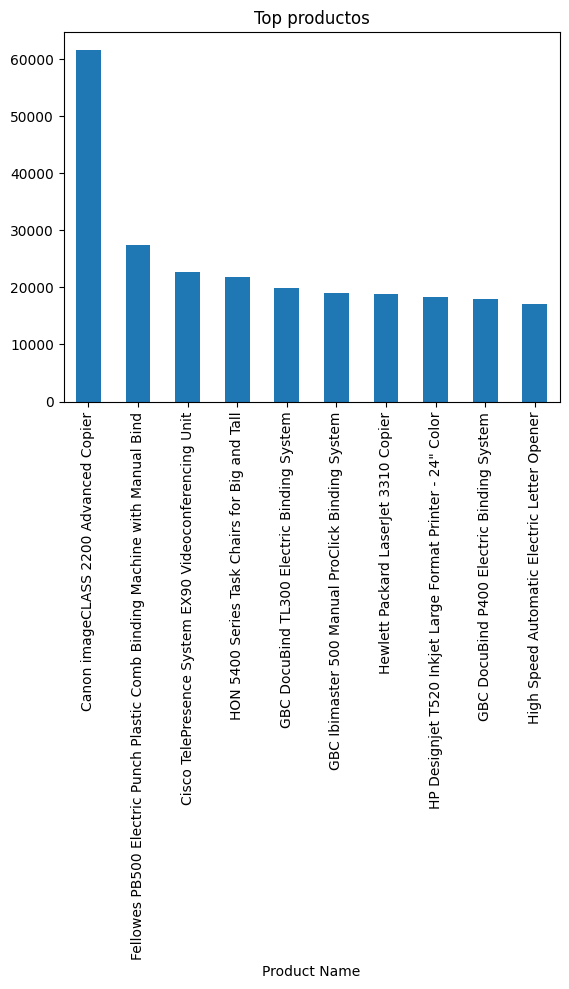

In [ ]:
top_products.plot(kind="bar", title="Top productos")
plt.show()


En este gráfico se analizan las ventas por categoría.

Esto permite entender qué tipo de productos tienen mayor impacto en el negocio
y cuáles son menos relevantes.

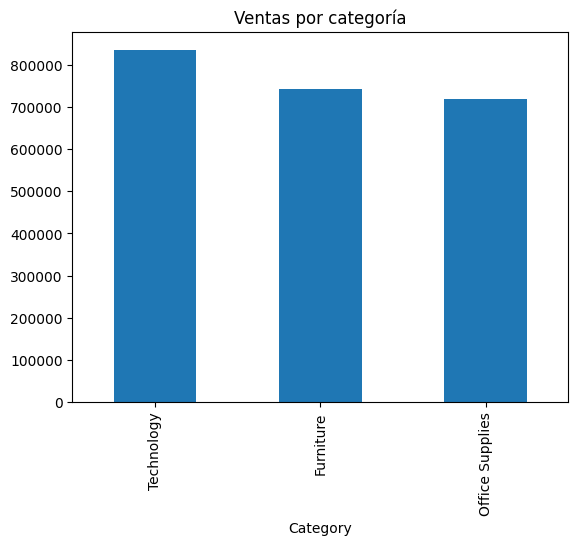

In [ ]:
sales_by_category.plot(kind="bar", title="Ventas por categoría")
plt.show()


Conclusiones:

- Se identificaron los productos con mayor volumen de ventas.
- Se observaron patrones en las ventas a lo largo del tiempo.
- Algunas categorías destacan significativamente sobre otras en términos de ingresos.

Este análisis permite tomar decisiones informadas para mejorar el rendimiento del negocio.
